In [1]:
import math
import torch; torch.manual_seed(0)
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt; plt.rcParams['figure.dpi'] = 200

from torch import Tensor, nn


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


#### Example

In [3]:
# 1D Sinuisoidal Positional Embedding
class SinusoidalPositionalEmbedding(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        self.embedding_dim = embedding_dim

    def forward(self, timesteps):
        positions = np.arange(timesteps)[:, np.newaxis]  # Shape: (timesteps, 1)
        dimensions = np.arange(self.embedding_dim)[
            np.newaxis, :
        ]  # Shape: (1, embedding_dim)

        # Compute angles using sine for even indices and cosine for odd indices
        angle_rates = 1 / np.power(10000, (2 * (dimensions // 2)) / self.embedding_dim)
        angle_rads = positions * angle_rates

        pos_encoding = np.zeros_like(angle_rads)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        return pos_encoding

Embeddings shape: (100, 128)


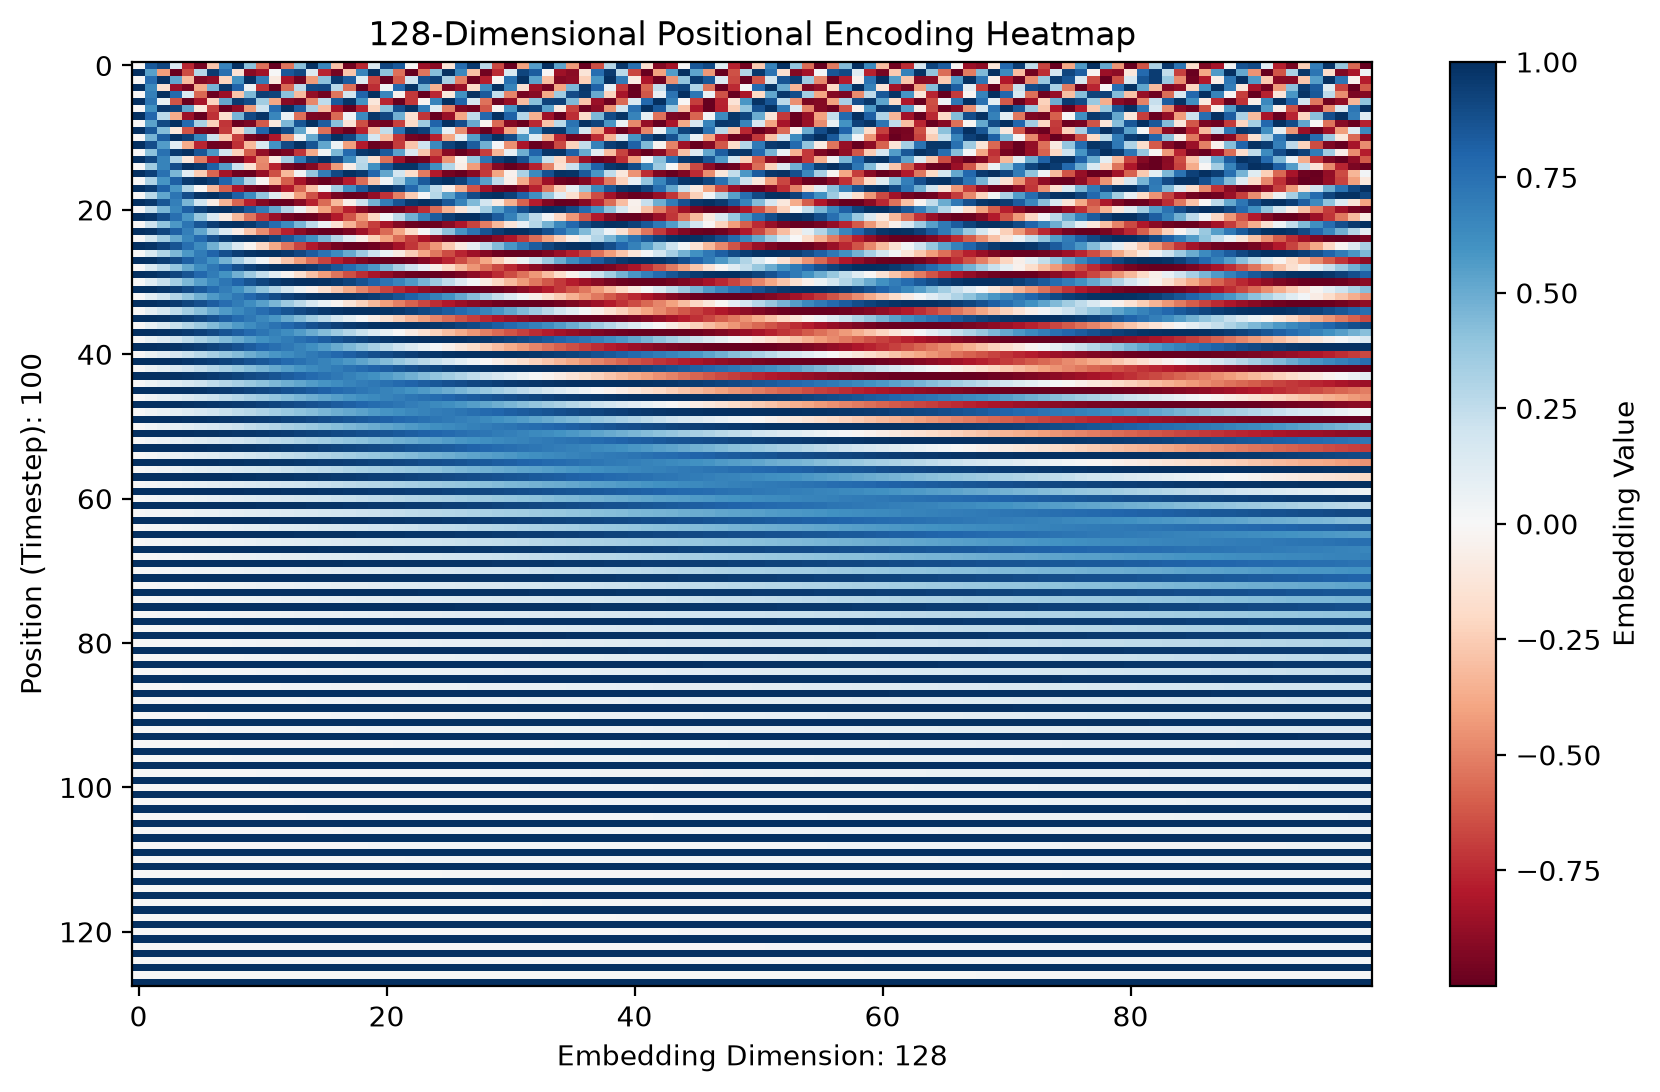

In [4]:
embedding_dim = 128  # Match embedding dimension from the reference
timesteps = 100  # Number of rows (timesteps)

# Generate Embeddings
embedding = SinusoidalPositionalEmbedding(embedding_dim)
embeddings = embedding(timesteps)  # Shape: [timesteps, embedding_dim]
print(f"Embeddings shape: {embeddings.shape}")  # Should be [timesteps, embedding_dim]

# Plot Heatmap
plt.figure(figsize=(10, 6))
plt.imshow(embeddings.T, aspect="auto", cmap="RdBu")
plt.colorbar(label="Embedding Value")
plt.title("{0}-Dimensional Positional Encoding Heatmap".format(embedding_dim))
plt.xlabel("Embedding Dimension: {0}".format(embedding_dim))
plt.ylabel("Position (Timestep): {0}".format(timesteps))
plt.show()

In [5]:
def get_safe_dtype(target_dtype, device_type):
    """Get a safe dtype for the given device type."""
    if device_type == "mps" and target_dtype == torch.float64:
        return torch.float32
    if device_type == "cpu":
        # CPU doesn't support bfloat16, use float32 instead
        if target_dtype == torch.bfloat16:
            return torch.float32
        if target_dtype == torch.float64:
            return torch.float64
    return target_dtype


def create_sinusoidal_pos_embedding(  # see openpi `create_sinusoidal_pos_embedding` (exact copy)
    time: torch.Tensor, dimension: int, min_period: float, max_period: float, device="cpu"
) -> Tensor:
    """Computes sine-cosine positional embedding vectors for scalar positions."""
    if dimension % 2 != 0:
        raise ValueError(f"dimension ({dimension}) must be divisible by 2")

    if time.ndim != 1:
        raise ValueError("The time tensor is expected to be of shape `(batch_size, )`.")

    # dtype = get_safe_dtype(torch.float64, device.type)
    fraction = torch.linspace(0.0, 1.0, dimension // 2, dtype=torch.float64, device=device)
    period = min_period * (max_period / min_period) ** fraction

    # Compute the outer product
    scaling_factor = 1.0 / period * 2 * math.pi
    sin_input = scaling_factor[None, :] * time[:, None]
    return torch.cat([torch.sin(sin_input), torch.cos(sin_input)], dim=1)

In [6]:
timesteps = torch.arange(0, 1000, device=device)  # (timesteps, 1)
embeddings = create_sinusoidal_pos_embedding(timesteps, 16, 1.0, 10000.0, device=device)

print(f"Embeddings shape: {embeddings.shape}")  # Should be [timesteps, embedding_dim]

Embeddings shape: torch.Size([1000, 16])


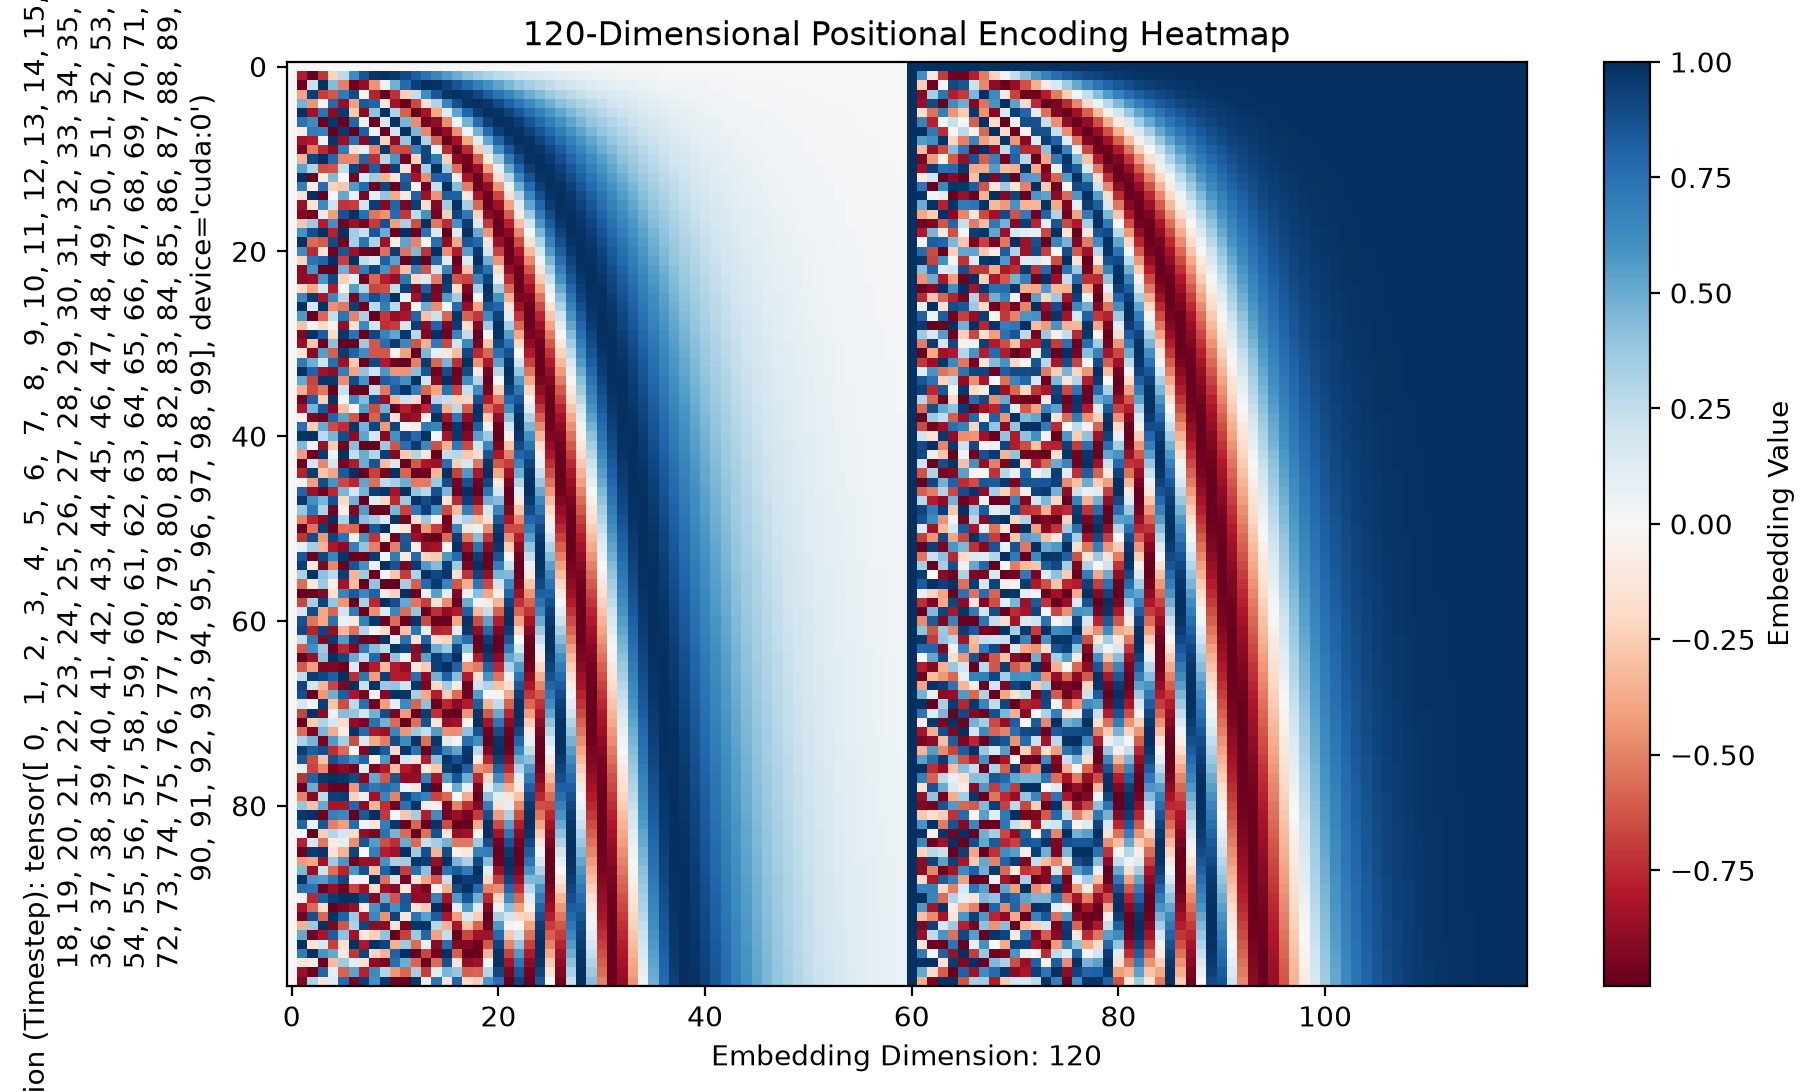

In [7]:
%matplotlib inline
embedding_dim = 120
timesteps = torch.arange(0, 100, device=device)  # (timesteps, 1)

embeddings = create_sinusoidal_pos_embedding(timesteps, embedding_dim, 1.0, 10000.0, device=device)

# Plot Heatmap
plt.figure(figsize=(10, 6))
plt.imshow(embeddings.cpu().numpy(), aspect="auto", cmap="RdBu")
plt.colorbar(label="Embedding Value")
plt.title("{0}-Dimensional Positional Encoding Heatmap".format(embedding_dim))
plt.xlabel("Embedding Dimension: {0}".format(embedding_dim))
plt.ylabel("Position (Timestep): {0}".format(timesteps))
plt.show()

##### From U-net example

In [8]:
class SinusoidalPosEmb(nn.Module):
    # TODO: Investigate
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        device = x.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = x[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb
    


Embeddings shape: torch.Size([100, 120])


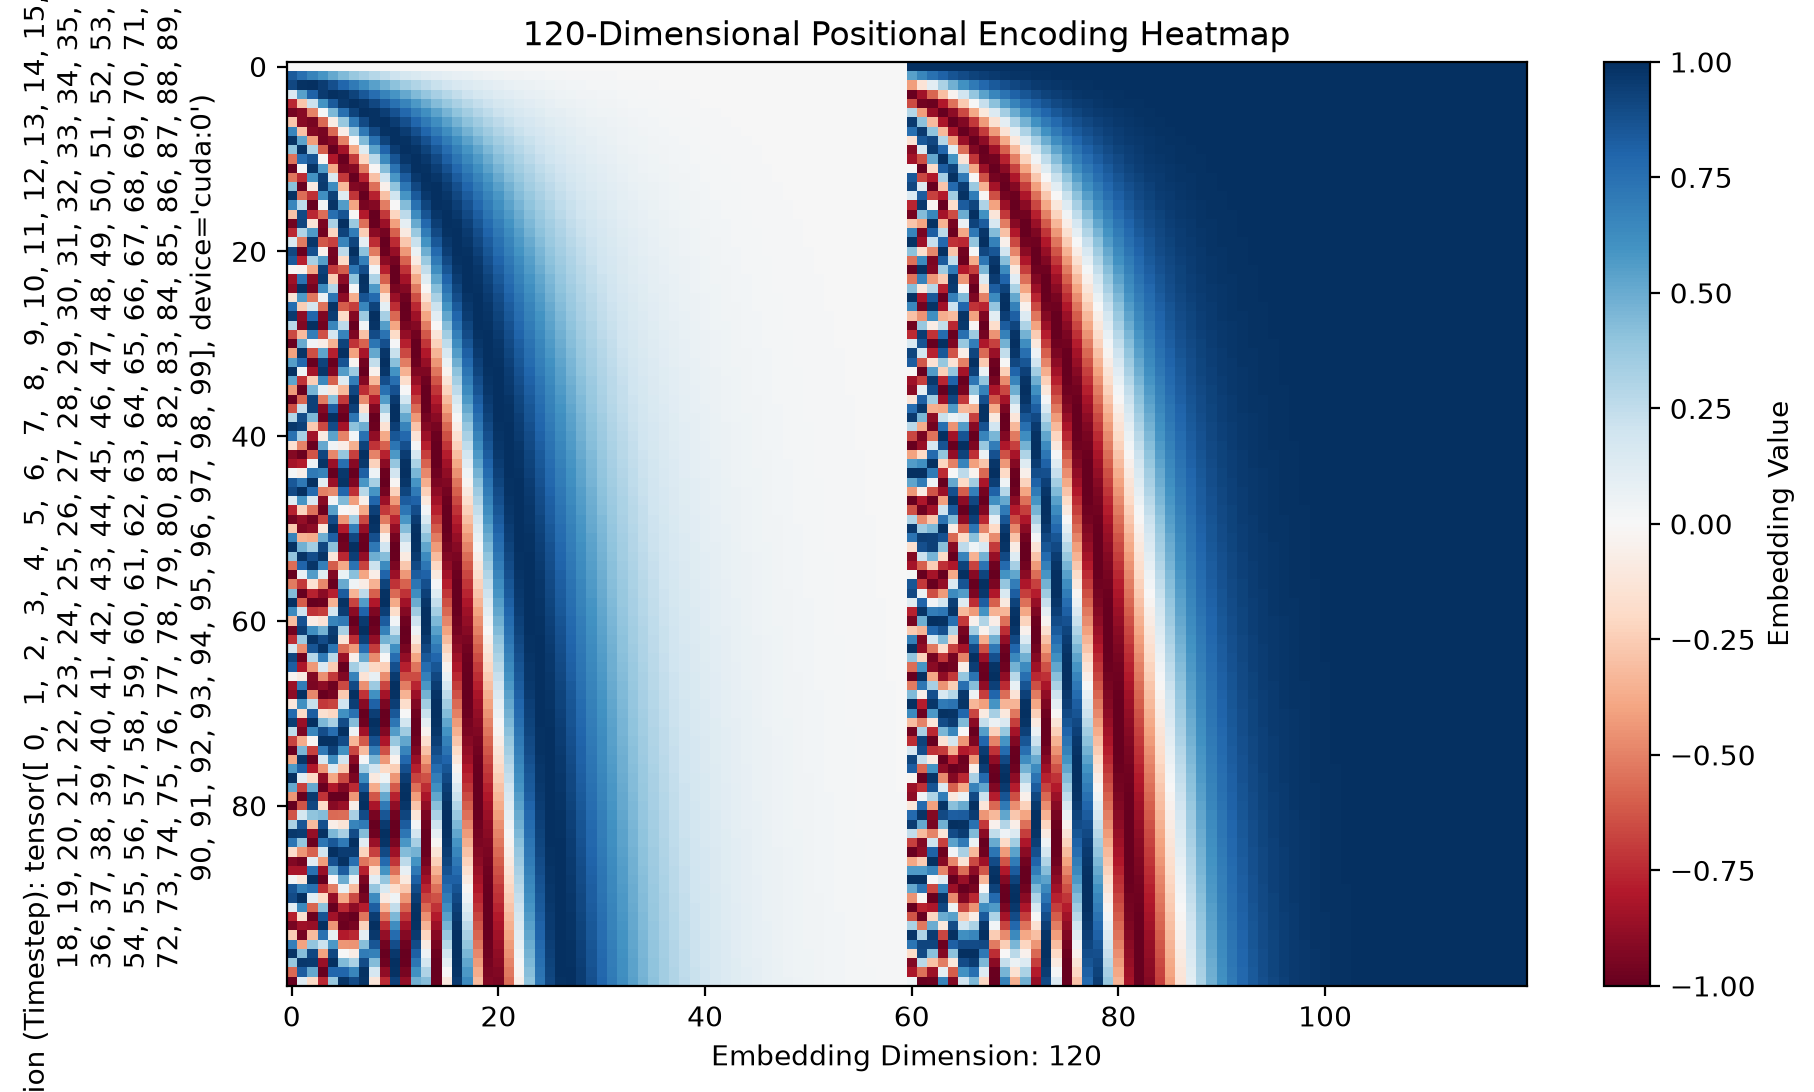

In [9]:
%matplotlib inline
embedding_dim = 120
timesteps = torch.arange(0, 100, device=device)  # (timesteps, 1)
# timesteps = torch.tensor(100)

sin_emb = SinusoidalPosEmb(embedding_dim)
embeddings = sin_emb(timesteps)
print(f"Embeddings shape: {embeddings.shape}")  # Should be [timesteps, embedding_dim]

# Plot Heatmap
plt.figure(figsize=(10, 6))
plt.imshow(embeddings.cpu().numpy(), aspect="auto", cmap="RdBu")
plt.colorbar(label="Embedding Value")
plt.title("{0}-Dimensional Positional Encoding Heatmap".format(embedding_dim))
plt.xlabel("Embedding Dimension: {0}".format(embedding_dim))
plt.ylabel("Position (Timestep): {0}".format(timesteps))
plt.show()

In [10]:
# Resource:
# https://apxml.com/courses/intro-diffusion-models/chapter-4-model-architecture-training/hands-on-unet-setup
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim # The dimension of the embeddings

    def forward(self, time):
        """
        Generates sinusoidal embeddings for a batch of timesteps.

        Args:
            time (torch.Tensor): A tensor of shape (batch_size,) containing timesteps.

        Returns:
            torch.Tensor: A tensor of shape (batch_size, dim) containing the embeddings.
        """
        device = time.device
        half_dim = self.dim // 2
        # Calculate frequencies (exponents for 10000)
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        # Calculate arguments for sine and cosine
        embeddings = time[:, None] * embeddings[None, :]
        # Concatenate sine and cosine components
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        # Handle odd dimensions if necessary (though typically 'dim' is even)
        if self.dim % 2 == 1:
             embeddings = torch.cat([embeddings, torch.zeros_like(embeddings[:, :1])], dim=-1)
        return embeddings

Embeddings shape: torch.Size([100, 120])


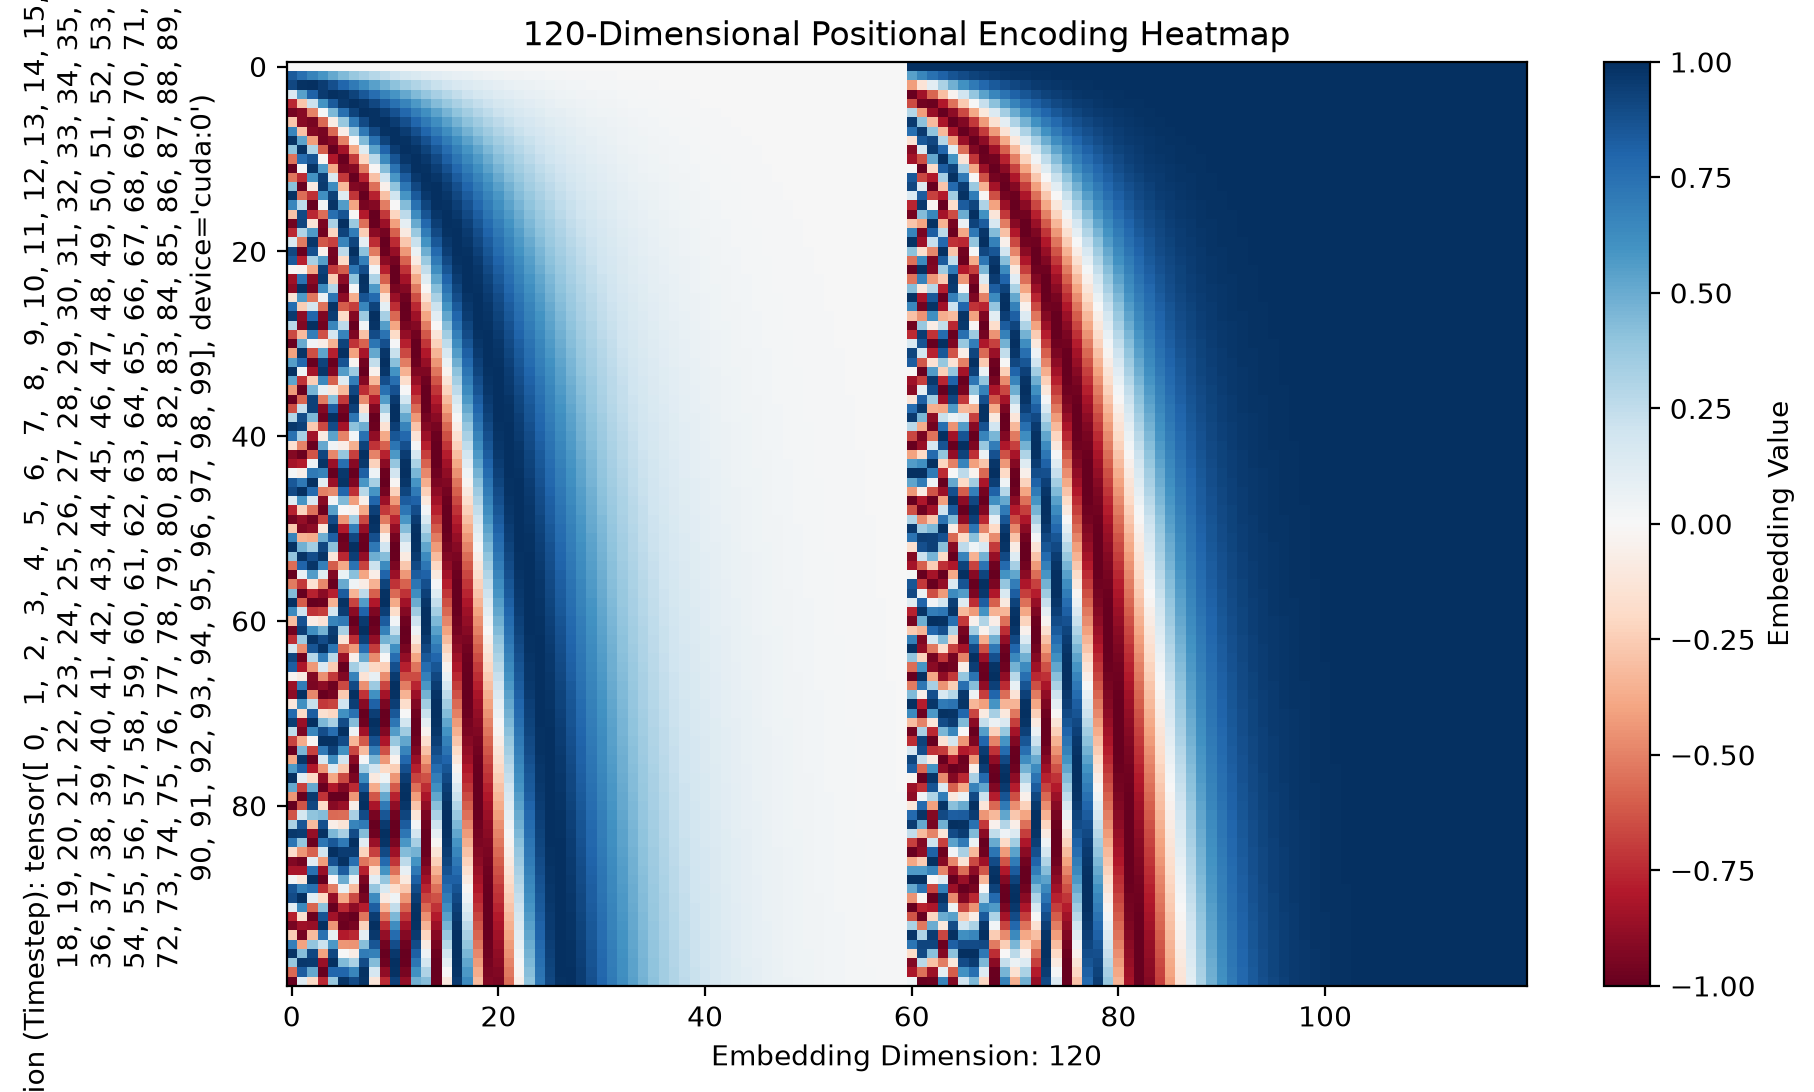

In [19]:
%matplotlib inline
embedding_dim = 120
timesteps = torch.arange(0, 100, device=device)  # (timesteps, 1)
# timesteps = torch.tensor(100)

sin_emb = SinusoidalPosEmb(embedding_dim)
embeddings = sin_emb(timesteps)
print(f"Embeddings shape: {embeddings.shape}")  # Should be [timesteps, embedding_dim]

# Plot Heatmap
plt.figure(figsize=(10, 6))
plt.imshow(embeddings.cpu().numpy(), aspect="auto", cmap="RdBu")
plt.colorbar(label="Embedding Value")
plt.title("{0}-Dimensional Positional Encoding Heatmap".format(embedding_dim))
plt.xlabel("Embedding Dimension: {0}".format(embedding_dim))
plt.ylabel("Position (Timestep): {0}".format(timesteps))
plt.show()

#### Implementation

In [11]:
timesteps = torch.arange(0, 100, device=device)  # (timesteps, )
print(f"Timesteps shape: {timesteps.shape}")  # Should be [timesteps]

Timesteps shape: torch.Size([100])


In [12]:
timesteps.view(-1, 1).shape

torch.Size([100, 1])

In [13]:
positions = torch.arange(timesteps.shape[0])
print(f"Positions shape: {positions.shape}")  # Should be [timesteps]
print(f"Positions: {positions}")  # Should be [0, 1, 2, ..., timesteps-1]

Positions shape: torch.Size([100])
Positions: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
        54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71,
        72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89,
        90, 91, 92, 93, 94, 95, 96, 97, 98, 99])


In [14]:
dim = 8
half_dim = dim // 2
torch.arange(half_dim, device=device)  # (half_dim, )

print(f"half_dim: {half_dim}")
print(f"torch.arange(half_dim, device=device): {torch.arange(half_dim, device=device)}")

half_dim: 4
torch.arange(half_dim, device=device): tensor([0, 1, 2, 3], device='cuda:0')


In [15]:
dim = 10
timesteps = torch.arange(0, 5, device=device)  # (timesteps, )

even = torch.arange(0, 2*dim // 2, 2, device=device)    # (dim/2, )
odd = torch.arange(1, 2*dim // 2, 2, device=device)     # (dim/2, )

print(f"timesteps: {timesteps}\n")
print(f"even: {even}")
print(f"odd: {odd}")

timesteps: tensor([0, 1, 2, 3, 4], device='cuda:0')

even: tensor([0, 2, 4, 6, 8], device='cuda:0')
odd: tensor([1, 3, 5, 7, 9], device='cuda:0')


In [16]:
print(f"timesteps[:, None]: {timesteps[:, None].shape}")  # Shape: (timesteps, 1)
print(f"even[None, :]: {even[None, :].shape}")  # Shape: (1, dim/2)
print(f"odd[None, :]: {odd[None, :].shape}")  # Shape: (1, dim/2)

even_timestep_emb = torch.sin(timesteps[:, None] * even[None, :])
odd_timestep_emb = torch.cos(timesteps[:, None] * odd[None, :])
output_emb = torch.zeros(timesteps.shape[0], dim, device=device)
output_emb[:, 0::2] = even_timestep_emb
output_emb[:, 1::2] = odd_timestep_emb
print()
print(f"even_timestep_emb: {even_timestep_emb.shape}")  # Shape: (timesteps, dim/2)
print(f"odd_timestep_emb: {odd_timestep_emb.shape}")  # Shape: (timesteps, dim/2)
print(f"output_emb: {output_emb.shape}")  # Shape: (timesteps, dim)

timesteps[:, None]: torch.Size([5, 1])
even[None, :]: torch.Size([1, 5])
odd[None, :]: torch.Size([1, 5])

even_timestep_emb: torch.Size([5, 5])
odd_timestep_emb: torch.Size([5, 5])
output_emb: torch.Size([5, 10])


In [17]:
def create_sinuisoidal_position_embeddings(time, dim):

    if dim % 2 != 0:
        raise ValueError("Embedding dimension must be even.")
    if time.ndim != 1:
        raise ValueError("Time must be a 1D tensor. (batch_size, )")

    # timesteps: (timesteps, 1)
    # pos is time step, dim is embedding dimension
    positions = torch.arange(timesteps.shape[0], device=device)  # (timesteps, )

    even = torch.arange(0, 2*dim // 2, 2, device=device)     # (dim/2, )
    odd = torch.arange(1, 2*dim // 2, 2, device=device)      # (dim/2, )
    even = torch.pow(10000, -even / dim)
    odd = torch.pow(10000, -odd / dim)
    
    even_timestep_emb = torch.sin(timesteps[:, None] * even[None, :])
    odd_timestep_emb = torch.cos(timesteps[:, None] * odd[None, :])
    output_emb = torch.zeros(timesteps.shape[0], dim, device=device)
    output_emb[:, 0::2] = even_timestep_emb
    output_emb[:, 1::2] = odd_timestep_emb

    return output_emb

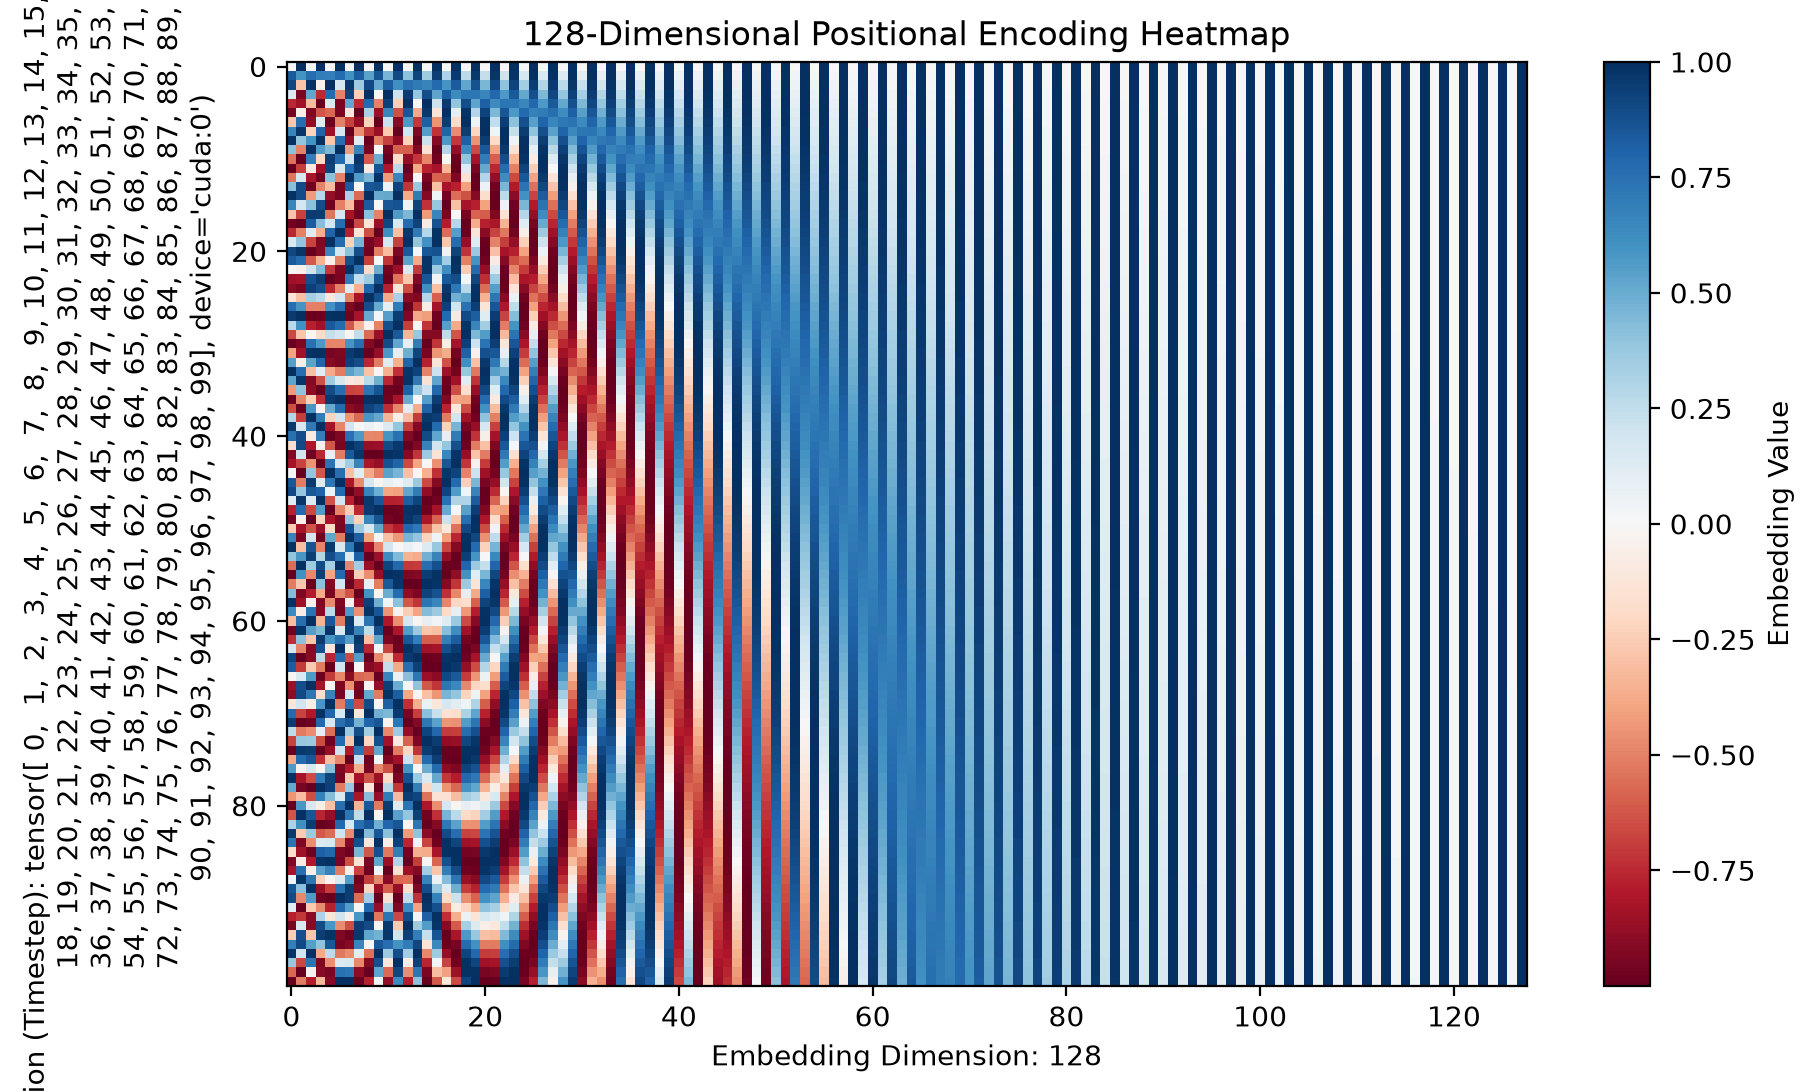

In [18]:
timesteps = torch.arange(0, 100, device=device)  # (timesteps, )
embedding_dim = 128

# Compute sinuisoidal position embeddings
embeddings = create_sinuisoidal_position_embeddings(timesteps, embedding_dim)

# Plot Heatmap
plt.figure(figsize=(10, 6))
plt.imshow(embeddings.cpu().numpy(), aspect="auto", cmap="RdBu")
plt.colorbar(label="Embedding Value")
plt.title("{0}-Dimensional Positional Encoding Heatmap".format(embedding_dim))
plt.xlabel("Embedding Dimension: {0}".format(embedding_dim))
plt.ylabel("Position (Timestep): {0}".format(timesteps))
plt.show()